# Project 2 - Hospital Bed Simulation
Student id: `s214985`



The assignment describes a loss/overflow system rather than a physical waiting queue:

- Ward A patients are relocated if Ward A is full.
- Ward B patients first try Ward B, then overflow to Ward A, and are relocated only if both are full.
- Ward C patients are relocated if Ward C is full.

Because of that, admitted patients have zero actual in-hospital queueing time. To still reflect the queueing-time idea, the notebook also reports a **virtual waiting time**: how long a blocked patient would have waited for the next eligible bed if relocation had not been allowed.

## 1. Primary task

This section builds the reusable simulation model itself. The code is written as functions so we can change the number of beds, the arrival processes, the length-of-stay assumptions, and the simulation horizon without rewriting the model.

In [1]:
import heapq
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BASE_SEED = 1
HORIZON_DAYS = 365.0

N_BASELINE = 120
N_SHORTLIST = 60
N_COMPARISON = 100
TOP_CANDIDATES = 10

In [2]:
def rate_ward_a(t: float) -> float:
    return max(0.0, -(t**2) / 3650.0 + t / 10.0)


def rate_ward_b(t: float) -> float:
    return 0.2 * rate_ward_a(t)


def lognormal_from_mean_sd(mean: float, sd: float) -> dict:
    sigma2 = np.log(1.0 + (sd**2) / (mean**2))
    return {
        "dist": "lognormal",
        "mu": np.log(mean) - 0.5 * sigma2,
        "sigma": np.sqrt(sigma2),
        "mean": mean,
        "sd": sd,
    }


DEFAULT_ARRIVAL_SPECS = {
    "A": {
        "kind": "nonhomogeneous",
        "rate_fn": rate_ward_a,
        "lambda_max": rate_ward_a(182.5),
    },
    "B": {
        "kind": "nonhomogeneous",
        "rate_fn": rate_ward_b,
        "lambda_max": rate_ward_b(182.5),
    },
    "C": {"kind": "homogeneous", "rate": 6.0},
}

DEFAULT_LOS_SPECS = {
    "A": lognormal_from_mean_sd(8.0, 8.0),
    "B": lognormal_from_mean_sd(12.0, 12.0),
    "C": lognormal_from_mean_sd(10.0, 10.0),
}


def to_exponential_specs(los_specs: dict) -> dict:
    return {
        ward: {"dist": "exponential", "mean": spec["mean"]}
        for ward, spec in los_specs.items()
    }


def sample_arrivals(spec: dict, horizon: float, rng: np.random.Generator) -> list[float]:
    if spec["kind"] == "homogeneous":
        t = 0.0
        times = []
        while True:
            t += rng.exponential(1.0 / spec["rate"])
            if t > horizon:
                break
            times.append(t)
        return times

    t = 0.0
    times = []
    while True:
        t += rng.exponential(1.0 / spec["lambda_max"])
        if t > horizon:
            break
        if rng.random() <= spec["rate_fn"](t) / spec["lambda_max"]:
            times.append(t)
    return times


def sample_los(spec: dict, rng: np.random.Generator) -> float:
    if spec["dist"] == "lognormal":
        return rng.lognormal(spec["mu"], spec["sigma"])
    if spec["dist"] == "exponential":
        return rng.exponential(spec["mean"])
    raise ValueError(f"Unsupported LOS distribution: {spec['dist']}")


def replication_seeds(n_replications: int, base_seed: int = BASE_SEED) -> list[int]:
    children = np.random.SeedSequence(base_seed).spawn(n_replications)
    return [int(child.generate_state(1)[0]) for child in children]


def scale_allocation(reference_beds: dict, total_beds: int) -> dict:
    reference = np.array([reference_beds["A"], reference_beds["B"], reference_beds["C"]], dtype=float)
    raw = reference / reference.sum() * total_beds
    scaled = np.maximum(np.floor(raw).astype(int), 1)

    diff = total_beds - scaled.sum()
    fractions = raw - np.floor(raw)
    order = np.argsort(-fractions)

    i = 0
    while diff > 0:
        scaled[order[i % 3]] += 1
        diff -= 1
        i += 1

    while diff < 0:
        idx = int(np.argmax(scaled))
        if scaled[idx] > 1:
            scaled[idx] -= 1
            diff += 1
        else:
            break

    return {"A": int(scaled[0]), "B": int(scaled[1]), "C": int(scaled[2])}

In [3]:
def simulate_hospital_year(
    beds: dict,
    los_specs: dict | None = None,
    arrival_specs: dict | None = None,
    horizon: float = HORIZON_DAYS,
    seed: int = BASE_SEED,
    track_virtual_wait: bool = True,
) -> dict:
    beds = dict(beds)
    los_specs = los_specs or DEFAULT_LOS_SPECS
    arrival_specs = arrival_specs or DEFAULT_ARRIVAL_SPECS
    rng = np.random.default_rng(seed)

    event_heap = []
    for patient_type, spec in arrival_specs.items():
        for arrival_time in sample_arrivals(spec, horizon, rng):
            event_heap.append((arrival_time, 1, "arrival", patient_type))
    heapq.heapify(event_heap)

    departures_by_ward = {"A": [], "B": [], "C": []}
    occupied = {"A": 0, "B": 0, "C": 0}
    occupied_bed_time = {"A": 0.0, "B": 0.0, "C": 0.0}
    arrivals = {"A": 0, "B": 0, "C": 0}
    primary_full = {"A": 0, "B": 0, "C": 0}
    relocated = {"A": 0, "B": 0, "C": 0}
    virtual_waits = {"A": [], "B": [], "C": []}
    overflow_b_to_a = 0

    last_time = 0.0
    current_time = 0.0

    def next_wait(ward: str) -> float:
        heap = departures_by_ward[ward]
        return max(0.0, heap[0] - current_time) if heap else np.nan

    while event_heap:
        current_time, _, event_type, label = heapq.heappop(event_heap)
        if current_time > horizon:
            break

        dt = current_time - last_time
        for ward in occupied:
            occupied_bed_time[ward] += occupied[ward] * dt
        last_time = current_time

        if event_type == "departure":
            heapq.heappop(departures_by_ward[label])
            occupied[label] -= 1
            continue

        patient_type = label
        arrivals[patient_type] += 1

        if patient_type == "A":
            if occupied["A"] >= beds["A"]:
                primary_full["A"] += 1
                relocated["A"] += 1
                if track_virtual_wait:
                    virtual_waits["A"].append(next_wait("A"))
            else:
                departure_time = current_time + sample_los(los_specs["A"], rng)
                heapq.heappush(event_heap, (departure_time, 0, "departure", "A"))
                heapq.heappush(departures_by_ward["A"], departure_time)
                occupied["A"] += 1

        elif patient_type == "B":
            if occupied["B"] >= beds["B"]:
                primary_full["B"] += 1

            if occupied["B"] < beds["B"]:
                target_ward = "B"
            elif occupied["A"] < beds["A"]:
                target_ward = "A"
                overflow_b_to_a += 1
            else:
                relocated["B"] += 1
                if track_virtual_wait:
                    virtual_waits["B"].append(min(next_wait("A"), next_wait("B")))
                continue

            departure_time = current_time + sample_los(los_specs["B"], rng)
            heapq.heappush(event_heap, (departure_time, 0, "departure", target_ward))
            heapq.heappush(departures_by_ward[target_ward], departure_time)
            occupied[target_ward] += 1

        else:
            if occupied["C"] >= beds["C"]:
                primary_full["C"] += 1
                relocated["C"] += 1
                if track_virtual_wait:
                    virtual_waits["C"].append(next_wait("C"))
            else:
                departure_time = current_time + sample_los(los_specs["C"], rng)
                heapq.heappush(event_heap, (departure_time, 0, "departure", "C"))
                heapq.heappush(departures_by_ward["C"], departure_time)
                occupied["C"] += 1

    dt = horizon - last_time
    for ward in occupied:
        occupied_bed_time[ward] += occupied[ward] * dt

    utilization_a = occupied_bed_time["A"] / (beds["A"] * horizon)
    utilization_b = occupied_bed_time["B"] / (beds["B"] * horizon)
    utilization_c = occupied_bed_time["C"] / (beds["C"] * horizon)

    results = {
        "arrivals_A": arrivals["A"],
        "arrivals_B": arrivals["B"],
        "arrivals_C": arrivals["C"],
        "primary_full_prob_A": primary_full["A"] / arrivals["A"],
        "primary_full_prob_B": primary_full["B"] / arrivals["B"],
        "primary_full_prob_C": primary_full["C"] / arrivals["C"],
        "relocated_A": relocated["A"],
        "relocated_B": relocated["B"],
        "relocated_C": relocated["C"],
        "relocated_total": sum(relocated.values()),
        "utilization_A": utilization_a,
        "utilization_B": utilization_b,
        "utilization_C": utilization_c,
        "weighted_mean_utilization": (
            beds["A"] * utilization_a
            + beds["B"] * utilization_b
            + beds["C"] * utilization_c
        ) / sum(beds.values()),
        "overflow_B_to_A": overflow_b_to_a,
    }

    if track_virtual_wait:
        for patient_type in ("A", "B", "C"):
            waits = np.array(virtual_waits[patient_type], dtype=float)
            results[f"virtual_wait_if_blocked_{patient_type}"] = float(np.nanmean(waits)) if waits.size else 0.0

    return results


def run_replications(
    beds: dict,
    los_specs: dict | None = None,
    arrival_specs: dict | None = None,
    n_replications: int = 100,
    base_seed: int = BASE_SEED,
) -> pd.DataFrame:
    seeds = replication_seeds(n_replications, base_seed=base_seed)
    records = [
        simulate_hospital_year(
            beds=beds,
            los_specs=los_specs,
            arrival_specs=arrival_specs,
            seed=seed,
        )
        for seed in seeds
    ]
    return pd.DataFrame(records)


def confidence_interval(values: pd.Series, z_value: float = 1.96) -> tuple[float, float, float]:
    mean = float(values.mean())
    half_width = float(z_value * values.std(ddof=1) / np.sqrt(len(values)))
    return mean, mean - half_width, mean + half_width


def summarise_metrics(frame: pd.DataFrame, metric_map: dict, decimals: int = 4) -> pd.DataFrame:
    rows = []
    for label, column in metric_map.items():
        mean, ci_low, ci_high = confidence_interval(frame[column])
        rows.append(
            {
                "metric": label,
                "mean": mean,
                "ci_low": ci_low,
                "ci_high": ci_high,
            }
        )
    return pd.DataFrame(rows).set_index("metric").round(decimals)


def screen_bed_allocations(
    total_beds: int = 75,
    min_beds: dict | None = None,
    seed: int = BASE_SEED,
) -> pd.DataFrame:
    min_beds = min_beds or {"A": 1, "B": 1, "C": 1}
    rows = []

    for beds_a in range(min_beds["A"], total_beds - min_beds["B"] - min_beds["C"] + 1):
        max_b = total_beds - beds_a - min_beds["C"]
        for beds_b in range(min_beds["B"], max_b + 1):
            beds_c = total_beds - beds_a - beds_b
            if beds_c < min_beds["C"]:
                continue
            result = simulate_hospital_year(
                beds={"A": beds_a, "B": beds_b, "C": beds_c},
                seed=seed,
                track_virtual_wait=False,
            )
            rows.append(
                {
                    "A": beds_a,
                    "B": beds_b,
                    "C": beds_c,
                    "screen_relocated_total": result["relocated_total"],
                    "utilization_A": result["utilization_A"],
                    "utilization_B": result["utilization_B"],
                    "utilization_C": result["utilization_C"],
                    "weighted_mean_utilization": result["weighted_mean_utilization"],
                }
            )

    return pd.DataFrame(rows)

,single_run_output
arrivals_A,2262.0
arrivals_B,429.0
arrivals_C,2206.0
relocated_A,1155.0
relocated_B,129.0
relocated_C,927.0
relocated_total,2211.0


Building a 75-bed allocation map with seed 1...


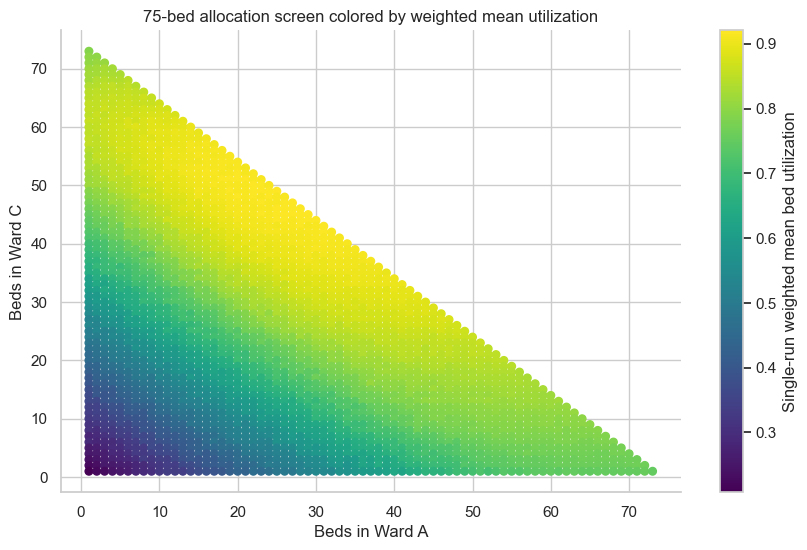

In [4]:
baseline_beds = {"A": 30, "B": 9, "C": 36}

single_run_example = pd.Series(simulate_hospital_year(baseline_beds, seed=BASE_SEED))
display(single_run_example[[
    "arrivals_A",
    "arrivals_B",
    "arrivals_C",
    "relocated_A",
    "relocated_B",
    "relocated_C",
    "relocated_total",
]].to_frame("single_run_output"))

print("Building a 75-bed allocation map with seed 1...")
screen_results = screen_bed_allocations(total_beds=75, seed=BASE_SEED)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    screen_results["A"],
    screen_results["C"],
    c=screen_results["weighted_mean_utilization"],
    cmap="viridis",
    s=30,
)
plt.colorbar(scatter, label="Single-run weighted mean bed utilization")
plt.xlabel("Beds in Ward A")
plt.ylabel("Beds in Ward C")
plt.title("75-bed allocation screen colored by weighted mean utilization")
plt.show()

# Example of how the model can be re-used with dynamic inputs:
# alternative_beds = {"A": 28, "B": 4, "C": 43}
# alternative_los = dict(DEFAULT_LOS_SPECS)
# alternative_los["A"] = lognormal_from_mean_sd(mean=7.0, sd=6.0)
# alternative_runs = run_replications(alternative_beds, los_specs=alternative_los, n_replications=50)

## 2. Primary performance measures

This section estimates the main project outputs for a baseline 75-bed allocation. We report the probability that the primary ward is full on arrival, the average number of relocated patients by type and in total, the average ward utilization, and the virtual waiting time as an auxiliary congestion metric.

In [5]:
baseline_runs = run_replications(baseline_beds, n_replications=N_BASELINE)

blocking_summary = summarise_metrics(
    baseline_runs,
    {
        "Ward A full on A-arrival": "primary_full_prob_A",
        "Ward B full on B-arrival": "primary_full_prob_B",
        "Ward C full on C-arrival": "primary_full_prob_C",
    },
    decimals=4,
)

relocation_summary = summarise_metrics(
    baseline_runs,
    {
        "Relocated A-patients": "relocated_A",
        "Relocated B-patients": "relocated_B",
        "Relocated C-patients": "relocated_C",
        "Relocated patients in total": "relocated_total",
    },
    decimals=1,
)

utilization_summary = summarise_metrics(
    baseline_runs,
    {
        "Ward A utilization": "utilization_A",
        "Ward B utilization": "utilization_B",
        "Ward C utilization": "utilization_C",
        "ICU overflow from B to A": "overflow_B_to_A",
    },
    decimals=4,
)

virtual_wait_summary = summarise_metrics(
    baseline_runs,
    {
        "Virtual wait if blocked: A-type": "virtual_wait_if_blocked_A",
        "Virtual wait if blocked: B-type": "virtual_wait_if_blocked_B",
        "Virtual wait if blocked: C-type": "virtual_wait_if_blocked_C",
    },
    decimals=4,
)

display(blocking_summary)
display(relocation_summary)
display(utilization_summary)
display(virtual_wait_summary)

,mean,ci_low,ci_high
metric,,,
Ward A full on A-arrival,0.5269,0.5241,0.5298
Ward B full on B-arrival,0.5037,0.4979,0.5095
Ward C full on C-arrival,0.4107,0.4073,0.4140


,mean,ci_low,ci_high
metric,,,
Relocated A-patients,1172.6,1163.6,1181.7
Relocated B-patients,136.0,133.1,139.0
Relocated C-patients,900.1,890.0,910.3
Relocated patients in total,2208.8,2195.5,2222.1


,mean,ci_low,ci_high
metric,,,
Ward A utilization,0.8604,0.8584,0.8623
Ward B utilization,0.8016,0.7975,0.8056
Ward C utilization,0.9550,0.9543,0.9558
ICU overflow from B to A,88.4250,86.4894,90.3606


,mean,ci_low,ci_high
metric,,,
Virtual wait if blocked: A-type,0.2696,0.2662,0.2729
Virtual wait if blocked: B-type,0.2251,0.2208,0.2295
Virtual wait if blocked: C-type,0.2678,0.2648,0.2708


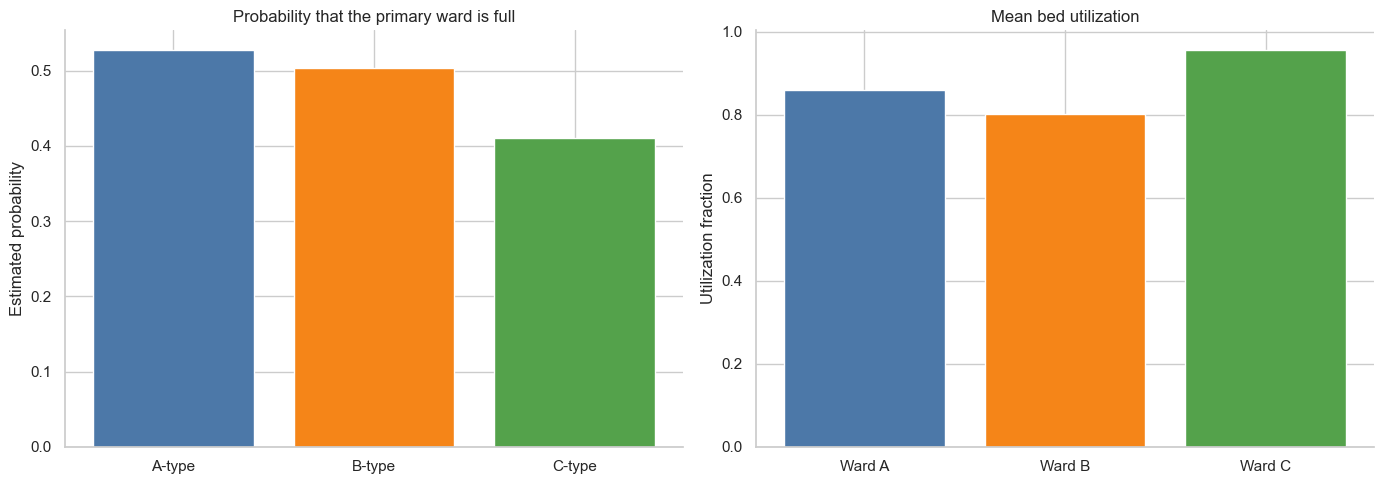

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    ["A-type", "B-type", "C-type"],
    [
        baseline_runs["primary_full_prob_A"].mean(),
        baseline_runs["primary_full_prob_B"].mean(),
        baseline_runs["primary_full_prob_C"].mean(),
    ],
    color=["#4C78A8", "#F58518", "#54A24B"],
)
axes[0].set_title("Probability that the primary ward is full")
axes[0].set_ylabel("Estimated probability")

axes[1].bar(
    ["Ward A", "Ward B", "Ward C"],
    [
        baseline_runs["utilization_A"].mean(),
        baseline_runs["utilization_B"].mean(),
        baseline_runs["utilization_C"].mean(),
    ],
    color=["#4C78A8", "#F58518", "#54A24B"],
)
axes[1].set_title("Mean bed utilization")
axes[1].set_ylabel("Utilization fraction")

plt.tight_layout()
plt.show()

The baseline results already indicate a very stressed system. With only 75 beds in total, the model spends most of the year near capacity, especially in Ward C, so relocations become a more meaningful congestion measure than actual in-hospital waiting.

## 3. Sensitivity analysis

This section studies how the conclusions change when the bed mix is adjusted, when the LOS distribution is changed from lognormal to exponential, and when the total number of beds is increased or decreased. The main optimization target is the mean number of relocated patients.

,A,B,C,screen_relocated_total,utilization_A,utilization_B,utilization_C,weighted_mean_utilization
0,37,1,37,2150,0.868628,0.921131,0.955212,0.912043
1,38,1,36,2154,0.859058,0.901472,0.955843,0.906080
2,31,2,42,2156,0.881759,0.854786,0.946739,0.917428
3,29,1,45,2157,0.880765,0.890000,0.947502,0.920930
4,37,2,36,2158,0.857392,0.847404,0.958763,0.905784
5,30,3,42,2160,0.882821,0.836446,0.943834,0.915133
6,36,1,38,2160,0.864001,0.890958,0.955335,0.910636
7,34,1,40,2161,0.867819,0.890777,0.951841,0.912937
8,32,1,42,2163,0.879661,0.840495,0.943491,0.914884
9,31,3,41,2164,0.875585,0.858227,0.947807,0.914372


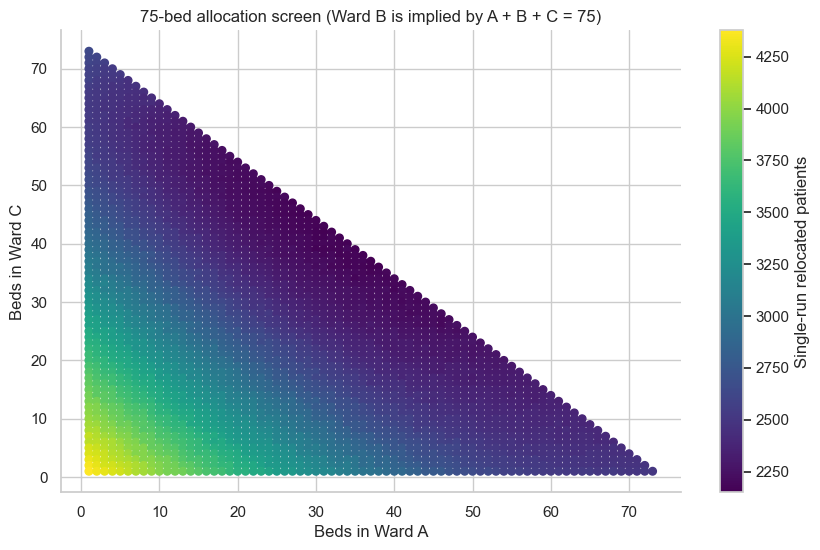

In [7]:
shortlist = screen_results.nsmallest(TOP_CANDIDATES, "screen_relocated_total").reset_index(drop=True)

display(shortlist)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    screen_results["A"],
    screen_results["C"],
    c=screen_results["screen_relocated_total"],
    cmap="viridis",
    s=30,
)
plt.colorbar(scatter, label="Single-run relocated patients")
plt.xlabel("Beds in Ward A")
plt.ylabel("Beds in Ward C")
plt.title("75-bed allocation screen (Ward B is implied by A + B + C = 75)")
plt.show()

In [8]:
candidate_rows = []
for row in shortlist.itertuples(index=False):
    beds = {"A": row.A, "B": row.B, "C": row.C}
    runs = run_replications(beds, n_replications=N_SHORTLIST)
    candidate_rows.append(
        {
            "A": row.A,
            "B": row.B,
            "C": row.C,
            "mean_relocated_total": runs["relocated_total"].mean(),
            "mean_full_prob_A": runs["primary_full_prob_A"].mean(),
            "mean_full_prob_B": runs["primary_full_prob_B"].mean(),
            "mean_full_prob_C": runs["primary_full_prob_C"].mean(),
            "mean_util_A": runs["utilization_A"].mean(),
            "mean_util_B": runs["utilization_B"].mean(),
            "mean_util_C": runs["utilization_C"].mean(),
        }
    )

candidate_summary = pd.DataFrame(candidate_rows).sort_values("mean_relocated_total").reset_index(drop=True)
best_beds = candidate_summary.loc[0, ["A", "B", "C"]].astype(int).to_dict()

display(candidate_summary.round(4))
print("Best 75-bed allocation under the relocation objective:", best_beds)

,A,B,C,mean_relocated_total,mean_full_prob_A,mean_full_prob_B,mean_full_prob_C,mean_util_A,mean_util_B,mean_util_C
0,34,1,40,2148.1667,0.5227,0.9393,0.3476,0.8705,0.8943,0.9482
1,32,1,42,2150.2333,0.5474,0.9354,0.3203,0.8761,0.8944,0.9448
2,36,1,38,2150.6667,0.4960,0.9367,0.3813,0.8641,0.8918,0.9517
3,37,1,37,2153.1833,0.4842,0.9383,0.3975,0.8598,0.8964,0.9539
4,29,1,45,2153.3667,0.5833,0.9374,0.2772,0.8846,0.8914,0.9390
5,38,1,36,2153.9500,0.4733,0.9351,0.4116,0.8584,0.8972,0.9552
6,31,2,42,2155.1333,0.5525,0.8736,0.3208,0.8747,0.8820,0.9453
7,37,2,36,2158.6667,0.4779,0.8735,0.4120,0.8570,0.8821,0.9551
8,30,3,42,2160.1333,0.5585,0.8173,0.3213,0.8745,0.8742,0.9459
9,31,3,41,2163.0167,0.5462,0.8185,0.3375,0.8707,0.8706,0.9472


Best 75-bed allocation under the relocation objective: {'A': 34, 'B': 1, 'C': 40}


A useful modeling insight appears here: minimizing total relocations alone pushes Ward B toward the minimum feasible size, because Ward B patients can spill over into Ward A, while Ward C patients are lost immediately when Ward C is full. If ICU access should be protected more strongly, the objective function should penalize Ward B blocking or Ward B relocations more heavily.

,scenario,los_distribution,relocated_total,full_prob_A,full_prob_B,full_prob_C,util_A,util_B,util_C
0,Baseline,Lognormal,2206.37,0.5263,0.5024,0.4112,0.8602,0.8005,0.9552
1,Baseline,Exponential,2205.85,0.5260,0.5000,0.4114,0.8610,0.7964,0.9540
2,Near-optimal,Lognormal,2144.82,0.5226,0.9383,0.3473,0.8699,0.8941,0.9483
3,Near-optimal,Exponential,2147.24,0.5214,0.9378,0.3497,0.8681,0.8922,0.9478


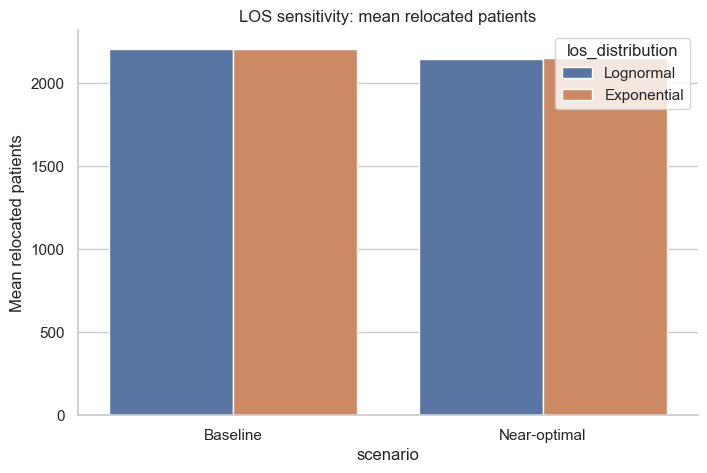

In [9]:
los_comparison_rows = []
exponential_los = to_exponential_specs(DEFAULT_LOS_SPECS)

for scenario_name, beds in [("Baseline", baseline_beds), ("Near-optimal", best_beds)]:
    for los_name, los_specs in [("Lognormal", DEFAULT_LOS_SPECS), ("Exponential", exponential_los)]:
        runs = run_replications(beds, los_specs=los_specs, n_replications=N_COMPARISON)
        los_comparison_rows.append(
            {
                "scenario": scenario_name,
                "los_distribution": los_name,
                "relocated_total": runs["relocated_total"].mean(),
                "full_prob_A": runs["primary_full_prob_A"].mean(),
                "full_prob_B": runs["primary_full_prob_B"].mean(),
                "full_prob_C": runs["primary_full_prob_C"].mean(),
                "util_A": runs["utilization_A"].mean(),
                "util_B": runs["utilization_B"].mean(),
                "util_C": runs["utilization_C"].mean(),
            }
        )

los_comparison = pd.DataFrame(los_comparison_rows).round(4)
display(los_comparison)

plt.figure(figsize=(8, 5))
sns.barplot(data=los_comparison, x="scenario", y="relocated_total", hue="los_distribution")
plt.title("LOS sensitivity: mean relocated patients")
plt.ylabel("Mean relocated patients")
plt.show()

,total_beds,A,B,C,relocated_total,util_A,util_B,util_C
0,60,27,1,32,2651.28,0.8899,0.8978,0.9602
1,75,34,1,40,2144.82,0.8699,0.8941,0.9483
2,80,36,1,43,1983.70,0.8631,0.8945,0.9433
3,100,45,1,54,1383.90,0.8340,0.8968,0.9134


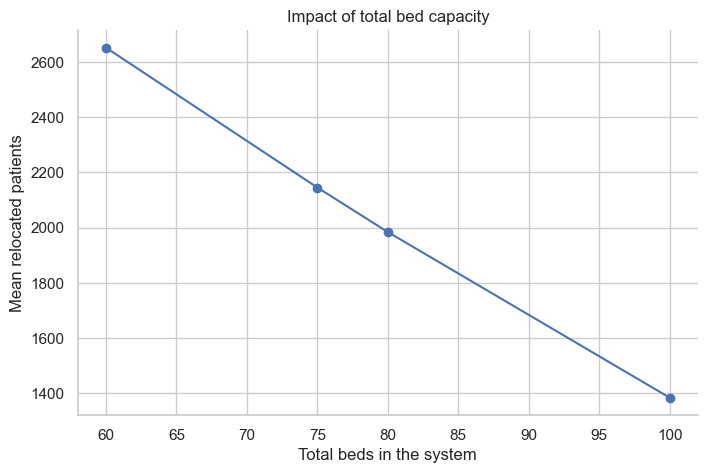

In [10]:
capacity_rows = []
for total_beds in [60, 75, 80, 100]:
    scaled_beds = scale_allocation(best_beds, total_beds)
    runs = run_replications(scaled_beds, n_replications=N_COMPARISON)
    capacity_rows.append(
        {
            "total_beds": total_beds,
            "A": scaled_beds["A"],
            "B": scaled_beds["B"],
            "C": scaled_beds["C"],
            "relocated_total": runs["relocated_total"].mean(),
            "util_A": runs["utilization_A"].mean(),
            "util_B": runs["utilization_B"].mean(),
            "util_C": runs["utilization_C"].mean(),
        }
    )

capacity_sensitivity = pd.DataFrame(capacity_rows).round(4)
display(capacity_sensitivity)

plt.figure(figsize=(8, 5))
plt.plot(capacity_sensitivity["total_beds"], capacity_sensitivity["relocated_total"], marker="o")
plt.title("Impact of total bed capacity")
plt.xlabel("Total beds in the system")
plt.ylabel("Mean relocated patients")
plt.show()